# MOO Electricity Forecast — Results Analysis

End-to-end analysis notebook: loads all raw results, produces every paper table and figure.

**Metric definitions (important for paper)**
- **NRMSE** = RMSE in z-score normalised space = RMSE_original / train_std
- **RMSE / MAE** = original MW scale (after z-score inversion)
- **MAPE** = stored in *percent* (e.g. `0.68` means `0.68%`); computed with denominator clipped at 1 MW
- **val_mse** = MSE in normalised (z-score) space — the optimisation objective, NOT MW²

**Outputs**
- `plots/` — PDF + PNG for every figure
- `tables/` — CSV + LaTeX `.tex` for every table

---
## Section 0 — Setup & Data Loading

In [37]:
import os, json, warnings
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import wilcoxon

warnings.filterwarnings('ignore')

# ---------- Paths ----------
# Notebook lives in <project_root>/notebooks/ so parent is the project root.
PROJECT_ROOT = pathlib.Path().resolve().parent
RESULTS_DIR  = PROJECT_ROOT / 'results'
PARETO_DIR   = RESULTS_DIR  / 'pareto_analysis'
PLOTS_DIR    = PROJECT_ROOT / 'plots'
TABLES_DIR   = PROJECT_ROOT / 'tables'

PLOTS_DIR.mkdir(exist_ok=True)
TABLES_DIR.mkdir(exist_ok=True)

# ---------- Constants ----------
SEEDS   = [0, 24, 42, 247, 296, 1981, 2005]
ZONES   = ['PJME', 'AEP', 'DAYTON']
METHODS = ['baseline', 'random_search', 'optuna', 'pso', 'moo']

METHOD_LABELS = {
    'baseline':      'Baseline',
    'random_search': 'Random Search',
    'optuna':        'Optuna (TPE)',
    'pso':           'PSO',
    'moo':           'MOO (NSGA-II)',
}

METHOD_COLORS = {
    'baseline':      '#7f7f7f',
    'random_search': '#1f77b4',
    'optuna':        '#2ca02c',
    'pso':           '#ff7f0e',
    'moo':           '#d62728',
}

TIER_BOUNDS  = {'Edge / Lightweight': (0, 20_000),
                'Mid-range':          (20_001, 200_000),
                'Full-capacity':      (200_001, float('inf'))}

TIER_COLORS  = {'Edge / Lightweight': '#2ca02c',
                'Mid-range':          '#ff7f0e',
                'Full-capacity':      '#1f77b4'}

PARETO_SEEDS = [0, 42]

# ---------- Global plot style ----------
plt.rcParams.update({
    'font.family':     'sans-serif',
    'font.size':        11,
    'axes.titlesize':   12,
    'axes.labelsize':   11,
    'xtick.labelsize':  10,
    'ytick.labelsize':  10,
    'legend.fontsize':  9,
    'figure.dpi':       150,
    'savefig.dpi':      300,
    'savefig.bbox':     'tight',
})

print(f'Project root: {PROJECT_ROOT}')
print(f'Plots  → {PLOTS_DIR}')
print(f'Tables → {TABLES_DIR}')

Project root: C:\Users\upadh\OneDrive\Desktop\Projects\Research Project\MOO-Electricity-Forecast
Plots  → C:\Users\upadh\OneDrive\Desktop\Projects\Research Project\MOO-Electricity-Forecast\plots
Tables → C:\Users\upadh\OneDrive\Desktop\Projects\Research Project\MOO-Electricity-Forecast\tables


In [38]:
# ---------- Load all 105 equal-budget metrics ----------
records = []
for seed in SEEDS:
    for zone in ZONES:
        for method in METHODS:
            path = RESULTS_DIR / f'seed_{seed}' / zone / method / 'metrics.json'
            with open(path) as f:
                d = json.load(f)
            hp = d.get('best_hyperparams', {})
            records.append({
                'seed':        seed,
                'zone':        zone,
                'method':      method,
                'nrmse':       d['best_test_nrmse'],
                'rmse':        d['best_test_rmse'],
                'mae':         d['best_test_mae'],
                'mape':        d['best_test_mape'],   # already in %, e.g. 0.68 means 0.68%
                'val_mse':     d['best_val_mse'],
                'runtime_s':   d['runtime_s'],
                'convergence': d.get('convergence', []),
                'hidden_dim':  hp.get('hidden_dim'),
                'num_layers':  hp.get('num_layers'),
                'lr':          hp.get('lr'),
                'dropout':     hp.get('dropout'),
            })

df = pd.DataFrame(records)
print(f'Loaded {len(df)} result records.')
df.head()

Loaded 105 result records.


,seed,zone,method,nrmse,rmse,mae,mape,val_mse,runtime_s,convergence,hidden_dim,num_layers,lr,dropout
0,0,PJME,baseline,0.045647,296.548981,206.162155,0.659007,0.002882,243.44,[],128,1,0.004000,0.000000
1,0,PJME,random_search,0.041786,271.466278,189.261719,0.603508,0.002406,1548.60,"[0.0036985842584605823, 0.0036985842584605823,...",244,2,0.004408,0.107415
2,0,PJME,optuna,0.043538,282.842896,195.307831,0.623112,0.002987,1735.92,"[0.0059991877697086644, 0.0059991877697086644,...",228,1,0.004765,0.040503
3,0,PJME,pso,0.036558,237.501358,161.073120,0.512337,0.002140,2049.47,"[0.03694146534135519, 0.004729597930196943, 0....",237,3,0.005000,0.000198
4,0,PJME,moo,0.040773,264.885925,180.805267,0.575930,0.002527,1460.04,"[0.03694146534135519, 0.0050418693813451725, 0...",160,3,0.003158,0.000209


In [39]:
# ---------- Load Pareto-analysis CSVs (high-budget PJME) ----------
pareto_dfs     = {}
pareto_metrics = {}

for seed in PARETO_SEEDS:
    csv_path = PARETO_DIR / 'PJME' / f'seed_{seed}' / 'pareto_front.csv'
    met_path = PARETO_DIR / 'PJME' / f'seed_{seed}' / 'metrics.json'
    pareto_dfs[seed] = pd.read_csv(csv_path)
    with open(met_path) as f:
        pareto_metrics[seed] = json.load(f)

print('Pareto front sizes (high-budget, PJME):')
for seed in PARETO_SEEDS:
    n = len(pareto_dfs[seed])
    print(f'  Seed {seed}: {n} non-dominated solutions')

Pareto front sizes (high-budget, PJME):
  Seed 0: 12 non-dominated solutions
  Seed 42: 10 non-dominated solutions


---
## Section 1 — Completeness Audit

In [40]:
print('=' * 60)
print('COMPLETENESS AUDIT')
print('=' * 60)

# 1a. Row count
expected = len(SEEDS) * len(ZONES) * len(METHODS)
assert len(df) == expected, f'Expected {expected}, got {len(df)}'
print(f'[OK] All {expected} result files present (7 seeds x 3 zones x 5 methods)')

# 1b. No null metrics
metric_cols = ['nrmse', 'rmse', 'mae', 'mape']
nulls = df[metric_cols].isnull().sum()
assert nulls.sum() == 0, f'Null values: {nulls}'
print(f'[OK] No null metric values.')

# 1c. Budget verification: non-baseline methods should have 30-entry convergence
budget_issues = []
for _, row in df[df['method'] != 'baseline'].iterrows():
    n = len(row['convergence'])
    if n != 30:
        budget_issues.append((row['seed'], row['zone'], row['method'], n))
if budget_issues:
    print(f'[WARN] {len(budget_issues)} runs with convergence length != 30:')
    for s, z, m, n in budget_issues:
        print(f'       Seed {s}, {z}, {m}: {n} entries')
else:
    print(f'[OK] All non-baseline runs have exactly 30 convergence entries.')

# 1d. MOO vs Baseline flags
print('\n[MOO vs Baseline — cases where MOO >= Baseline NRMSE]')
baseline_idx = df[df['method'] == 'baseline'].set_index(['seed', 'zone'])['nrmse']
moo_idx      = df[df['method'] == 'moo'].set_index(['seed', 'zone'])['nrmse']

failure_rows = []
for (seed, zone) in baseline_idx.index:
    b = baseline_idx.loc[(seed, zone)]
    m = moo_idx.loc[(seed, zone)]
    if m >= b:
        failure_rows.append({'seed': seed, 'zone': zone,
                             'baseline_nrmse': round(b, 5),
                             'moo_nrmse':      round(m, 5),
                             'delta':          round(m - b, 5)})

if failure_rows:
    audit_df = pd.DataFrame(failure_rows)
    display(audit_df)
    audit_df.to_csv(TABLES_DIR / 'audit_moo_failures.csv', index=False)
    print(f'  --> {len(failure_rows)} failure(s). Saved to tables/audit_moo_failures.csv')
else:
    print('  None.')

# 1e. PSO boundary collapse
pso_df = df[df['method'] == 'pso']
lr_hits    = (pso_df['lr']         >= 0.00499).sum()
lay_hits   = (pso_df['num_layers'] == 4).sum()
print(f'\n[PSO boundary analysis]')
print(f'  lr hits max (>=0.00499): {lr_hits}/{len(pso_df)} runs ({100*lr_hits/len(pso_df):.0f}%)')
print(f'  num_layers = 4 (max):    {lay_hits}/{len(pso_df)} runs ({100*lay_hits/len(pso_df):.0f}%)')

COMPLETENESS AUDIT
[OK] All 105 result files present (7 seeds x 3 zones x 5 methods)
[OK] No null metric values.
[OK] All non-baseline runs have exactly 30 convergence entries.

[MOO vs Baseline — cases where MOO >= Baseline NRMSE]


,seed,zone,baseline_nrmse,moo_nrmse,delta
0,24,DAYTON,0.07094,0.07203,0.00109
1,247,PJME,0.04566,0.04871,0.00305
2,247,AEP,0.06070,0.06747,0.00678
3,247,DAYTON,0.07136,0.07688,0.00552
4,296,AEP,0.06014,0.06421,0.00407
5,1981,PJME,0.04483,0.05436,0.00954
6,1981,AEP,0.06091,0.06949,0.00858
7,1981,DAYTON,0.07139,0.07921,0.00782
8,2005,PJME,0.04509,0.04594,0.00085
9,2005,AEP,0.06107,0.06208,0.00101


  --> 11 failure(s). Saved to tables/audit_moo_failures.csv

[PSO boundary analysis]
  lr hits max (>=0.00499): 18/21 runs (86%)
  num_layers = 4 (max):    3/21 runs (14%)


---
## Section 2 — Main Comparison Table (Table 1)

In [41]:
# ---------- Aggregate across 7 seeds ----------
agg = df.groupby(['zone', 'method']).agg(
    nrmse_mean=('nrmse', 'mean'),  nrmse_std=('nrmse', 'std'),
    rmse_mean=('rmse',   'mean'),  rmse_std=('rmse',   'std'),
    mae_mean=('mae',     'mean'),  mae_std=('mae',     'std'),
    mape_mean=('mape',   'mean'),  mape_std=('mape',   'std'),
    runtime_mean=('runtime_s', 'mean'), runtime_std=('runtime_s', 'std'),
).reset_index()

# % improvement over baseline
bl = agg[agg['method'] == 'baseline'].set_index('zone')['nrmse_mean']
agg['nrmse_improv_pct'] = agg.apply(
    lambda r: 100 * (bl[r['zone']] - r['nrmse_mean']) / bl[r['zone']], axis=1
)

agg.round(6).to_csv(TABLES_DIR / 'main_comparison.csv', index=False)
print('Saved tables/main_comparison.csv')

Saved tables/main_comparison.csv


In [42]:
# ---------- Display: NRMSE mean ± std ----------
pivot_mean   = agg.pivot(index='method', columns='zone', values='nrmse_mean').loc[METHODS, ZONES]
pivot_std    = agg.pivot(index='method', columns='zone', values='nrmse_std').loc[METHODS, ZONES]
pivot_improv = agg.pivot(index='method', columns='zone', values='nrmse_improv_pct').loc[METHODS, ZONES]

display_df = pd.DataFrame(index=METHODS, columns=ZONES)
for m in METHODS:
    for z in ZONES:
        mu  = pivot_mean.loc[m, z]
        std = pivot_std.loc[m, z]
        imp = pivot_improv.loc[m, z]
        if m == 'baseline':
            display_df.loc[m, z] = f'{mu:.4f} ± {std:.4f}'
        else:
            display_df.loc[m, z] = f'{mu:.4f} ± {std:.4f}  ({imp:+.1f}%)'

display_df.index = [METHOD_LABELS[m] for m in METHODS]
print('Table 1: Mean NRMSE ± Std (7 seeds) with % improvement over baseline\n')
display(display_df)

Table 1: Mean NRMSE ± Std (7 seeds) with % improvement over baseline



,PJME,AEP,DAYTON
Baseline,0.0454 ± 0.0005,0.0606 ± 0.0003,0.0713 ± 0.0003
Random Search,0.0427 ± 0.0020 (+5.9%),0.0586 ± 0.0022 (+3.3%),0.0689 ± 0.0018 (+3.5%)
Optuna (TPE),0.0407 ± 0.0024 (+10.3%),0.0576 ± 0.0028 (+5.0%),0.0669 ± 0.0024 (+6.2%)
PSO,0.0416 ± 0.0038 (+8.4%),0.0549 ± 0.0032 (+9.4%),0.0680 ± 0.0023 (+4.7%)
MOO (NSGA-II),0.0458 ± 0.0047 (-0.8%),0.0621 ± 0.0056 (-2.3%),0.0729 ± 0.0038 (-2.2%)


In [43]:
# ---------- Full metric table (NRMSE, RMSE, MAE, MAPE) per zone ----------
for zone in ZONES:
    rows = []
    for m in METHODS:
        r = agg[(agg['zone'] == zone) & (agg['method'] == m)].iloc[0]
        rows.append({
            'Method':    METHOD_LABELS[m],
            'NRMSE':     f'{r.nrmse_mean:.4f} ± {r.nrmse_std:.4f}',
            'RMSE (MW)': f'{r.rmse_mean:.1f} ± {r.rmse_std:.1f}',
            'MAE (MW)':  f'{r.mae_mean:.1f} ± {r.mae_std:.1f}',
            'MAPE (%)':  f'{r.mape_mean:.3f} ± {r.mape_std:.3f}',
        })
    full_tbl = pd.DataFrame(rows).set_index('Method')
    print(f'\n--- Zone: {zone} ---')
    display(full_tbl)


--- Zone: PJME ---


,NRMSE,RMSE (MW),MAE (MW),MAPE (%)
Method,,,,
Baseline,0.0454 ± 0.0005,294.9 ± 3.4,204.0 ± 2.6,0.652 ± 0.009
Random Search,0.0427 ± 0.0020,277.6 ± 12.9,193.2 ± 10.2,0.617 ± 0.033
Optuna (TPE),0.0407 ± 0.0024,264.5 ± 15.8,183.2 ± 12.0,0.585 ± 0.039
PSO,0.0416 ± 0.0038,270.1 ± 24.8,189.2 ± 21.1,0.605 ± 0.069
MOO (NSGA-II),0.0458 ± 0.0047,297.2 ± 30.7,211.2 ± 27.9,0.675 ± 0.090



--- Zone: AEP ---


,NRMSE,RMSE (MW),MAE (MW),MAPE (%)
Method,,,,
Baseline,0.0606 ± 0.0003,156.3 ± 0.9,114.9 ± 0.5,0.783 ± 0.004
Random Search,0.0586 ± 0.0022,151.1 ± 5.6,111.9 ± 4.0,0.762 ± 0.028
Optuna (TPE),0.0576 ± 0.0028,148.5 ± 7.1,109.9 ± 5.4,0.748 ± 0.037
PSO,0.0549 ± 0.0032,141.6 ± 8.3,104.6 ± 6.3,0.712 ± 0.044
MOO (NSGA-II),0.0621 ± 0.0056,160.0 ± 14.4,118.5 ± 10.6,0.808 ± 0.073



--- Zone: DAYTON ---


,NRMSE,RMSE (MW),MAE (MW),MAPE (%)
Method,,,,
Baseline,0.0713 ± 0.0003,28.5 ± 0.1,19.2 ± 0.1,0.949 ± 0.007
Random Search,0.0689 ± 0.0018,27.5 ± 0.7,18.6 ± 0.6,0.920 ± 0.029
Optuna (TPE),0.0669 ± 0.0024,26.7 ± 0.9,17.9 ± 0.8,0.888 ± 0.040
PSO,0.0680 ± 0.0023,27.1 ± 0.9,18.3 ± 0.7,0.904 ± 0.036
MOO (NSGA-II),0.0729 ± 0.0038,29.1 ± 1.5,20.0 ± 1.4,0.990 ± 0.072


In [44]:
# ---------- LaTeX: main comparison table — bold best per zone ----------
def make_latex_comparison(pivot_mean, pivot_std, pivot_improv, methods, zones):
    # Identify best (lowest mean NRMSE) non-baseline method per zone
    best_per_zone = {}
    for z in zones:
        non_bl = {m: pivot_mean.loc[m, z] for m in methods if m != 'baseline'}
        best_per_zone[z] = min(non_bl, key=non_bl.get)

    col_spec = 'l' + 'c' * len(zones)
    header   = ' & '.join([f'\\textbf{{{z}}}' for z in zones])
    lines = [
        r'\begin{table}[htbp]',
        r'\centering',
        r'\caption{Test NRMSE (mean~$\pm$~std over 7 seeds) and percentage improvement over the',
        r'         fixed baseline. NRMSE~$= \text{RMSE}/\sigma_{\text{train}}$ (z-score normalisation).',
        r'         \textbf{Bold} = best-performing method per zone.}',
        r'\label{tab:main_comparison}',
        f'\\begin{{tabular}}{{{col_spec}}}',
        r'\toprule',
        f'\\textbf{{Method}} & {header} \\\\',
        r'\midrule',
    ]
    for m in methods:
        parts = [METHOD_LABELS[m]]
        for z in zones:
            mu  = pivot_mean.loc[m, z]
            std = pivot_std.loc[m, z]
            imp = pivot_improv.loc[m, z]
            if m == 'baseline':
                cell = f'{mu:.4f}~$\\pm$~{std:.4f}'
            else:
                cell = f'{mu:.4f}~$\\pm$~{std:.4f} ({imp:+.1f}\\%)'
            if best_per_zone[z] == m:
                cell = f'\\textbf{{{cell}}}'
            parts.append(cell)
        lines.append(' & '.join(parts) + r' \\')
        if m == 'baseline':
            lines.append(r'\midrule')
    lines += [r'\bottomrule', r'\end{tabular}', r'\end{table}']
    return '\n'.join(lines)

latex_cmp = make_latex_comparison(pivot_mean, pivot_std, pivot_improv, METHODS, ZONES)
(TABLES_DIR / 'main_comparison.tex').write_text(latex_cmp)
print('Saved tables/main_comparison.tex\n')
print(latex_cmp)

Saved tables/main_comparison.tex

\begin{table}[htbp]
\centering
\caption{Test NRMSE (mean~$\pm$~std over 7 seeds) and percentage improvement over the
         fixed baseline. NRMSE~$= \text{RMSE}/\sigma_{\text{train}}$ (z-score normalisation).
         \textbf{Bold} = best-performing method per zone.}
\label{tab:main_comparison}
\begin{tabular}{lccc}
\toprule
\textbf{Method} & \textbf{PJME} & \textbf{AEP} & \textbf{DAYTON} \\
\midrule
Baseline & 0.0454~$\pm$~0.0005 & 0.0606~$\pm$~0.0003 & 0.0713~$\pm$~0.0003 \\
\midrule
Random Search & 0.0427~$\pm$~0.0020 (+5.9\%) & 0.0586~$\pm$~0.0022 (+3.3\%) & 0.0689~$\pm$~0.0018 (+3.5\%) \\
Optuna (TPE) & \textbf{0.0407~$\pm$~0.0024 (+10.3\%)} & 0.0576~$\pm$~0.0028 (+5.0\%) & \textbf{0.0669~$\pm$~0.0024 (+6.2\%)} \\
PSO & 0.0416~$\pm$~0.0038 (+8.4\%) & \textbf{0.0549~$\pm$~0.0032 (+9.4\%)} & 0.0680~$\pm$~0.0023 (+4.7\%) \\
MOO (NSGA-II) & 0.0458~$\pm$~0.0047 (-0.8\%) & 0.0621~$\pm$~0.0056 (-2.3\%) & 0.0729~$\pm$~0.0038 (-2.2\%) \\
\bottomrule
\end

---
## Section 3 — Statistical Tests (Wilcoxon Signed-Rank)

In [45]:
# Pairs tested per zone (method_a vs method_b, two-sided)
TEST_PAIRS = [
    ('optuna',        'baseline'),
    ('pso',           'baseline'),
    ('random_search', 'baseline'),
    ('moo',           'baseline'),
    ('optuna',        'random_search'),
    ('pso',           'random_search'),
    ('optuna',        'pso'),
    ('moo',           'random_search'),
]

wil_records = []
for zone in ZONES:
    pivot = df[df['zone'] == zone].pivot(index='seed', columns='method', values='nrmse')
    for (m1, m2) in TEST_PAIRS:
        vals1 = pivot[m1].values
        vals2 = pivot[m2].values
        diff  = vals1 - vals2
        if np.all(diff == 0):
            stat, p = 0.0, 1.0
        else:
            try:
                stat, p = wilcoxon(vals1, vals2, alternative='two-sided')
            except Exception:
                stat, p = np.nan, np.nan
        wil_records.append({
            'zone':       zone,
            'method_a':   METHOD_LABELS[m1],
            'method_b':   METHOD_LABELS[m2],
            'mean_a':     vals1.mean(),
            'mean_b':     vals2.mean(),
            'statistic':  stat,
            'p_value':    p,
            'sig_5pct':   p < 0.05 if not np.isnan(p) else False,
            'a_worse':    (vals1.mean() > vals2.mean()) and (p < 0.05),  # A is sig. WORSE
        })

wil_df = pd.DataFrame(wil_records).round(4)
display(wil_df)
wil_df.to_csv(TABLES_DIR / 'wilcoxon_tests.csv', index=False)
print('\nSaved tables/wilcoxon_tests.csv')
print('\nNote: cases where sig_5pct=True AND a_worse=True mean method_a is significantly INFERIOR.')

,zone,method_a,method_b,mean_a,mean_b,statistic,p_value,sig_5pct,a_worse
0,PJME,Optuna (TPE),Baseline,0.0407,0.0454,0.0,0.0156,True,False
1,PJME,PSO,Baseline,0.0416,0.0454,2.0,0.0469,True,False
2,PJME,Random Search,Baseline,0.0427,0.0454,0.0,0.0156,True,False
3,PJME,MOO (NSGA-II),Baseline,0.0458,0.0454,13.0,0.9375,False,False
4,PJME,Optuna (TPE),Random Search,0.0407,0.0427,8.0,0.3750,False,False
5,PJME,PSO,Random Search,0.0416,0.0427,10.0,0.5781,False,False
6,PJME,Optuna (TPE),PSO,0.0407,0.0416,9.0,0.4688,False,False
7,PJME,MOO (NSGA-II),Random Search,0.0458,0.0427,6.0,0.2188,False,False
8,AEP,Optuna (TPE),Baseline,0.0576,0.0606,0.0,0.0156,True,False
9,AEP,PSO,Baseline,0.0549,0.0606,1.0,0.0312,True,False



Saved tables/wilcoxon_tests.csv

Note: cases where sig_5pct=True AND a_worse=True mean method_a is significantly INFERIOR.


In [46]:
# ---------- LaTeX: Wilcoxon table — fixed column spec, dagger for MOO-worse ----------
def make_latex_wilcoxon(wil_df):
    lines = [
        r'\begin{table}[htbp]',
        r'\centering',
        r'\caption{Wilcoxon signed-rank test $p$-values (7 paired seeds, two-sided).',
        r'         $^*$ = $p < 0.05$, Method$_A$ significantly better than Method$_B$.',
        r'         $^\dagger$ = $p < 0.05$, Method$_A$ significantly \emph{worse} than Method$_B$.}',
        r'\label{tab:wilcoxon}',
        r'\begin{tabular}{llccc}',   # 5 columns: zone, comparison, mean_a, mean_b, p
        r'\toprule',
        r'\textbf{Zone} & \textbf{Comparison} & $\bar{\varepsilon}_A$ & $\bar{\varepsilon}_B$ & $p$-value \\',
        r'\midrule',
    ]
    prev_zone = None
    for _, r in wil_df.iterrows():
        zlab      = r['zone'] if r['zone'] != prev_zone else ''
        prev_zone = r['zone']
        if r['a_worse']:
            sig = r'$^\dagger$'        # A is significantly WORSE
        elif r['sig_5pct'] and not r['a_worse']:
            sig = r'$^*$'              # A is significantly better
        else:
            sig = ''
        lines.append(
            f"{zlab} & {r['method_a']} vs {r['method_b']} & "
            f"{r['mean_a']:.4f} & {r['mean_b']:.4f} & "
            f"{r['p_value']:.3f}{sig} \\\\"
        )
    lines += [r'\bottomrule', r'\end{tabular}', r'\end{table}']
    return '\n'.join(lines)

latex_wil = make_latex_wilcoxon(wil_df)
(TABLES_DIR / 'wilcoxon_tests.tex').write_text(latex_wil)
print('Saved tables/wilcoxon_tests.tex\n')
print(latex_wil)

Saved tables/wilcoxon_tests.tex

\begin{table}[htbp]
\centering
\caption{Wilcoxon signed-rank test $p$-values (7 paired seeds, two-sided).
         $^*$ = $p < 0.05$, Method$_A$ significantly better than Method$_B$.
         $^\dagger$ = $p < 0.05$, Method$_A$ significantly \emph{worse} than Method$_B$.}
\label{tab:wilcoxon}
\begin{tabular}{llccc}
\toprule
\textbf{Zone} & \textbf{Comparison} & $\bar{\varepsilon}_A$ & $\bar{\varepsilon}_B$ & $p$-value \\
\midrule
PJME & Optuna (TPE) vs Baseline & 0.0407 & 0.0454 & 0.016$^*$ \\
 & PSO vs Baseline & 0.0416 & 0.0454 & 0.047$^*$ \\
 & Random Search vs Baseline & 0.0427 & 0.0454 & 0.016$^*$ \\
 & MOO (NSGA-II) vs Baseline & 0.0458 & 0.0454 & 0.938 \\
 & Optuna (TPE) vs Random Search & 0.0407 & 0.0427 & 0.375 \\
 & PSO vs Random Search & 0.0416 & 0.0427 & 0.578 \\
 & Optuna (TPE) vs PSO & 0.0407 & 0.0416 & 0.469 \\
 & MOO (NSGA-II) vs Random Search & 0.0458 & 0.0427 & 0.219 \\
AEP & Optuna (TPE) vs Baseline & 0.0576 & 0.0606 & 0.016$^*$ \\
 &

---
## Section 4 — Figure 1: Main Comparison Bar Chart

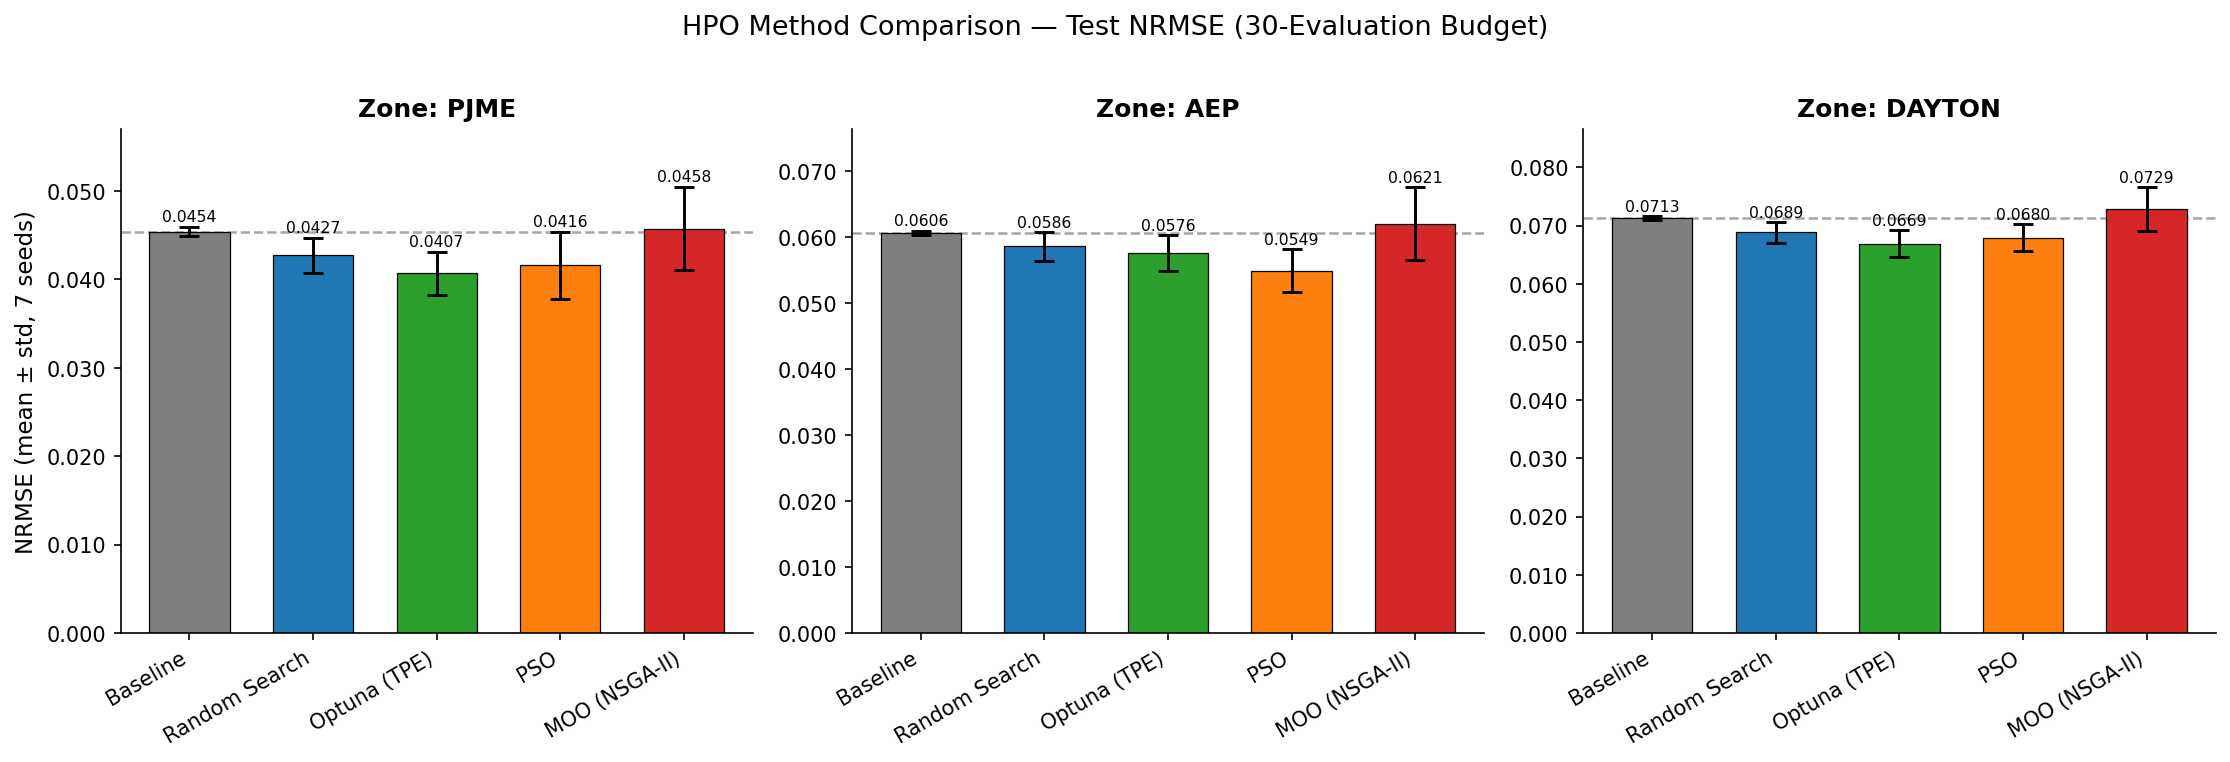

Saved fig1_bar_comparison.pdf/.png


In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, zone in zip(axes, ZONES):
    zone_agg = agg[agg['zone'] == zone].set_index('method').loc[METHODS]
    x      = np.arange(len(METHODS))
    colors = [METHOD_COLORS[m] for m in METHODS]

    ax.bar(
        x, zone_agg['nrmse_mean'],
        yerr=zone_agg['nrmse_std'],
        color=colors, capsize=5, width=0.65,
        edgecolor='black', linewidth=0.6,
        error_kw={'elinewidth': 1.4, 'ecolor': 'black', 'capthick': 1.4},
    )

    # Baseline reference line — helps eye gauge improvement without changing y-axis origin
    bl_val = zone_agg.loc['baseline', 'nrmse_mean']
    ax.axhline(bl_val, color='#7f7f7f', linestyle='--', linewidth=1.2,
               alpha=0.7, zorder=0, label='Baseline level')

    # Annotate bar tops with mean NRMSE value
    for xi, m in zip(x, METHODS):
        v   = zone_agg.loc[m, 'nrmse_mean']
        err = zone_agg.loc[m, 'nrmse_std']
        ax.text(xi, v + err + 0.0003, f'{v:.4f}',
                ha='center', va='bottom', fontsize=7.5)

    ax.set_xticks(x)
    ax.set_xticklabels([METHOD_LABELS[m] for m in METHODS], rotation=30, ha='right')
    ax.set_title(f'Zone: {zone}', fontweight='bold')
    ax.set_ylabel('NRMSE (mean ± std, 7 seeds)' if ax is axes[0] else '')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
    top = zone_agg['nrmse_mean'].max() + zone_agg['nrmse_std'].max()
    ax.set_ylim(0, top * 1.13)   # tighter top — bars fill more of the axis
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('HPO Method Comparison — Test NRMSE (30-Evaluation Budget)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'fig1_bar_comparison.pdf')
plt.savefig(PLOTS_DIR / 'fig1_bar_comparison.png')
plt.show()
print('Saved fig1_bar_comparison.pdf/.png')

---
## Section 5 — Figure 2: Box Plots (Seed Distribution)

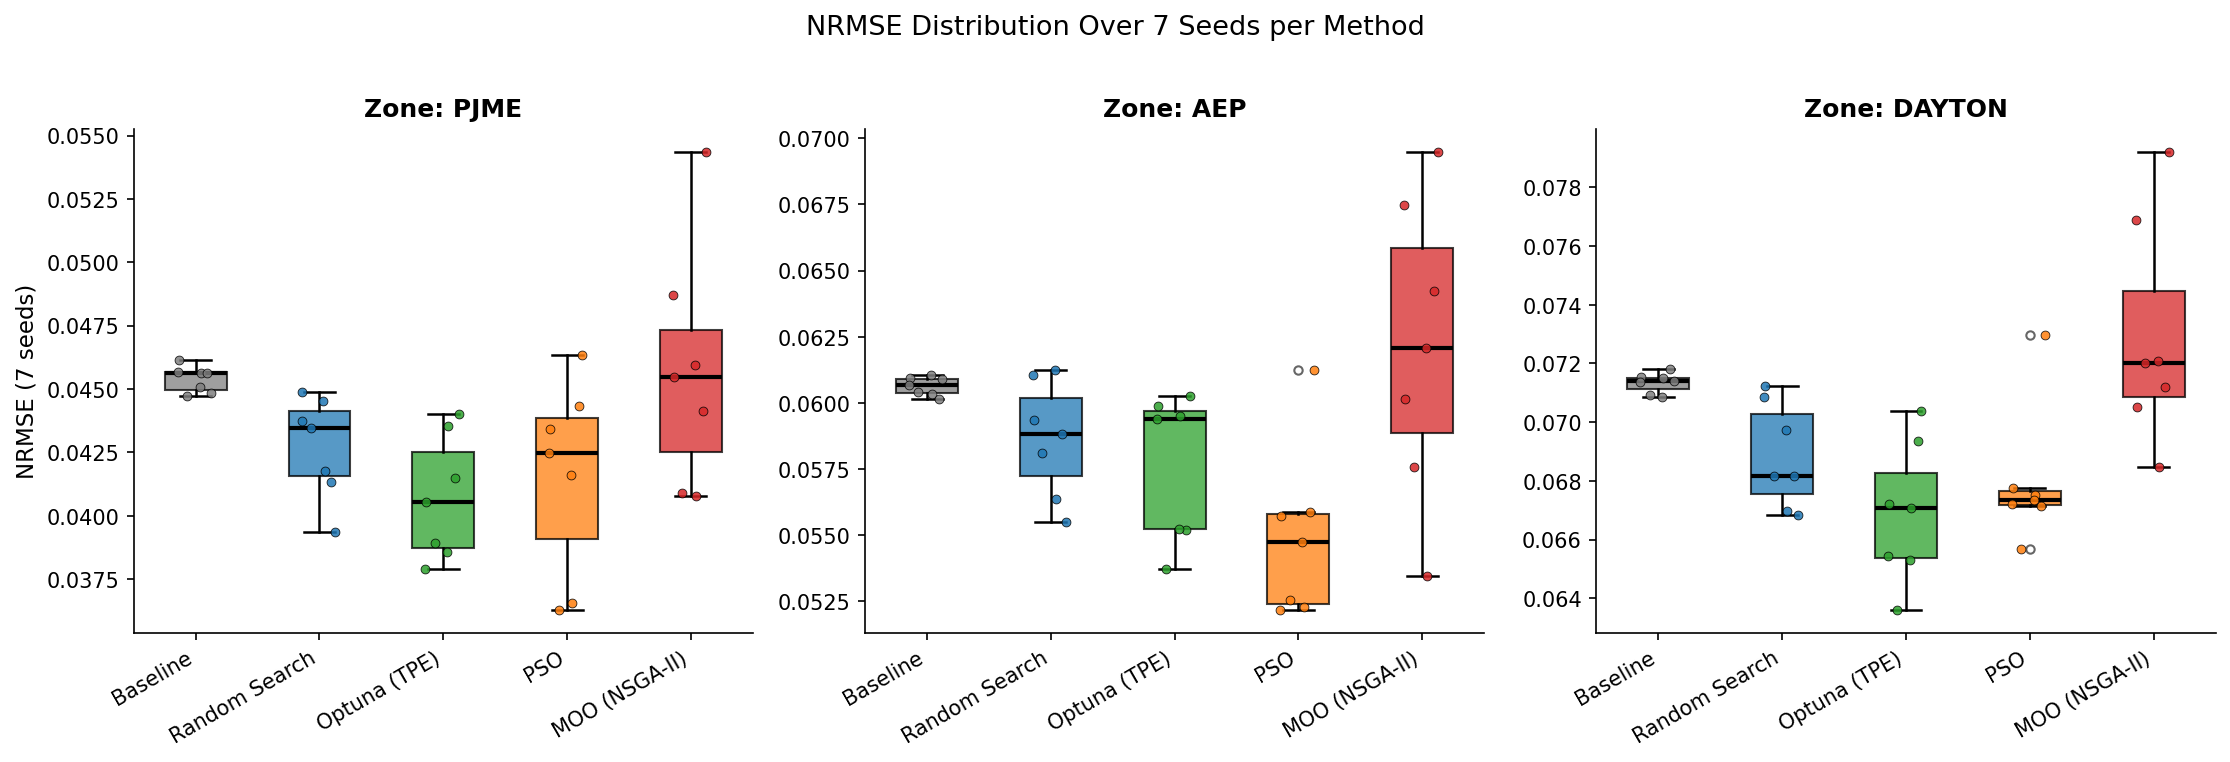

Saved fig2_boxplots.pdf/.png


In [48]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, zone in zip(axes, ZONES):
    zone_df   = df[df['zone'] == zone]
    plot_data = [zone_df[zone_df['method'] == m]['nrmse'].values for m in METHODS]

    bp = ax.boxplot(
        plot_data,
        patch_artist=True,
        notch=False,
        medianprops={'color': 'black', 'linewidth': 2},
        whiskerprops={'linewidth': 1.2},
        capprops={'linewidth': 1.2},
        flierprops={'marker': 'o', 'markersize': 4, 'alpha': 0.6},
    )
    for patch, m in zip(bp['boxes'], METHODS):
        patch.set_facecolor(METHOD_COLORS[m])
        patch.set_alpha(0.75)

    # Overlay individual seed points
    for i, (vals, m) in enumerate(zip(plot_data, METHODS), start=1):
        jitter = np.random.default_rng(0).uniform(-0.15, 0.15, size=len(vals))
        ax.scatter(i + jitter, vals, s=18, color=METHOD_COLORS[m],
                   alpha=0.85, zorder=5, edgecolors='black', linewidths=0.4)

    ax.set_xticks(range(1, len(METHODS) + 1))
    ax.set_xticklabels([METHOD_LABELS[m] for m in METHODS], rotation=30, ha='right')
    ax.set_title(f'Zone: {zone}', fontweight='bold')
    ax.set_ylabel('NRMSE (7 seeds)' if ax is axes[0] else '')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('NRMSE Distribution Over 7 Seeds per Method', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'fig2_boxplots.pdf')
plt.savefig(PLOTS_DIR / 'fig2_boxplots.png')
plt.show()
print('Saved fig2_boxplots.pdf/.png')

---
## Section 6 — Figure 3: Convergence Curves

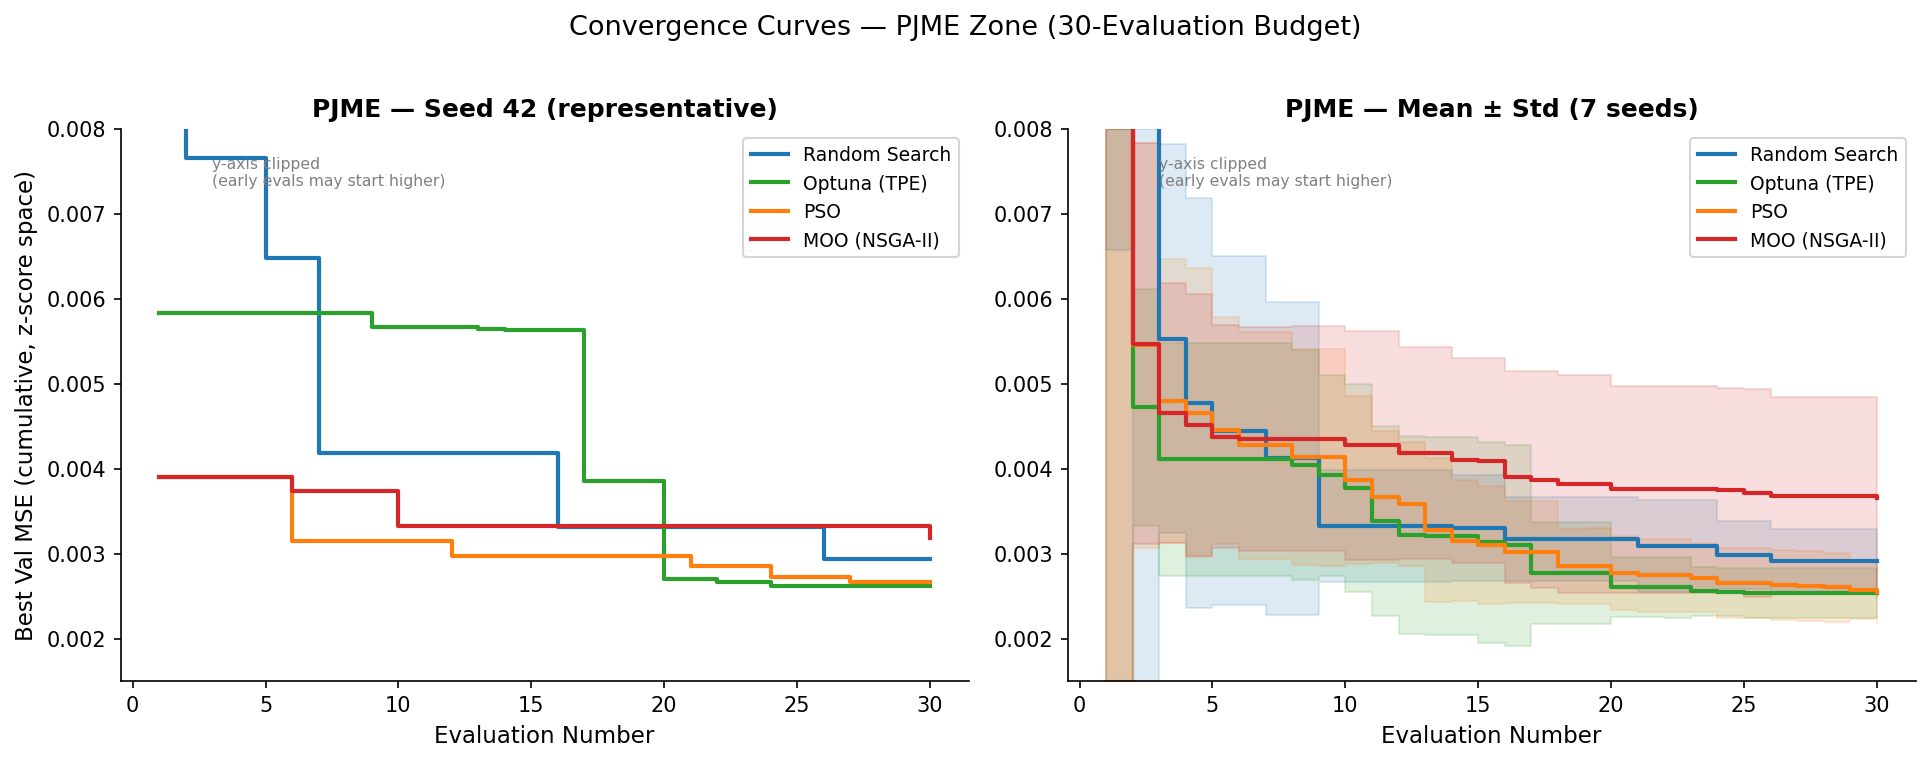

Saved fig3_convergence.pdf/.png


In [49]:
# Baseline excluded (no search / empty convergence list)
CONV_METHODS = ['random_search', 'optuna', 'pso', 'moo']

CONV_YMIN, CONV_YMAX = 0.0015, 0.0080

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

pjme_df = df[df['zone'] == 'PJME']

# -- Left: single representative run (seed 42) --
ax = axes[0]
for method in CONV_METHODS:
    row  = pjme_df[(pjme_df['seed'] == 42) & (pjme_df['method'] == method)].iloc[0]
    conv = np.array(row['convergence'])
    ax.step(range(1, len(conv) + 1), conv,
            where='post', color=METHOD_COLORS[method],
            label=METHOD_LABELS[method], linewidth=2)

ax.set_xlabel('Evaluation Number')
ax.set_ylabel('Best Val MSE (cumulative, z-score space)')
ax.set_title('PJME — Seed 42 (representative)', fontweight='bold')
ax.set_ylim(CONV_YMIN, CONV_YMAX)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.annotate('y-axis clipped\n(early evals may start higher)',
            xy=(1, CONV_YMAX), xytext=(3, CONV_YMAX * 0.96),
            fontsize=7.5, color='gray', va='top')

# -- Right: mean ± std over all 7 seeds --
ax = axes[1]
for method in CONV_METHODS:
    all_conv = pjme_df[pjme_df['method'] == method]['convergence'].tolist()
    valid = np.array([c for c in all_conv if len(c) == 30])
    if len(valid) == 0:
        continue
    mean_c = valid.mean(axis=0)
    std_c  = valid.std(axis=0, ddof=1)   # ddof=1 for unbiased sample std (n=7 seeds)
    x = range(1, 31)
    ax.step(x, mean_c, where='post',
            color=METHOD_COLORS[method], label=METHOD_LABELS[method], linewidth=2)
    ax.fill_between(x,
                    np.clip(mean_c - std_c, CONV_YMIN, CONV_YMAX),
                    np.clip(mean_c + std_c, CONV_YMIN, CONV_YMAX),
                    step='post', color=METHOD_COLORS[method], alpha=0.15)

ax.set_xlabel('Evaluation Number')
ax.set_title('PJME — Mean ± Std (7 seeds)', fontweight='bold')
ax.set_ylim(CONV_YMIN, CONV_YMAX)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.annotate('y-axis clipped\n(early evals may start higher)',
            xy=(1, CONV_YMAX), xytext=(3, CONV_YMAX * 0.96),
            fontsize=7.5, color='gray', va='top')

fig.suptitle('Convergence Curves — PJME Zone (30-Evaluation Budget)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'fig3_convergence.pdf')
plt.savefig(PLOTS_DIR / 'fig3_convergence.png')
plt.show()
print('Saved fig3_convergence.pdf/.png')


---
## Section 7 — Pareto Front Analysis (High-Budget MOO)

In [50]:
# ---------- 7a. Summary ----------
print('=' * 60)
print('PARETO FRONT SUMMARY — PJME High-Budget (150 evals)')
print('=' * 60)

for seed in PARETO_SEEDS:
    m  = pareto_metrics[seed]
    pf = pareto_dfs[seed]
    print(f'\nSeed {seed}:')
    print(f'  Solutions:        {m["n_pareto_solutions"]}')
    print(f'  Best val MSE:     {m["best_val_mse"]:.6f}  (z-score space)')
    print(f'  Best test NRMSE:  {m["best_test_nrmse"]:.4f}  '
          f'RMSE: {m["best_test_rmse"]:.1f} MW  '
          f'MAE: {m["best_test_mae"]:.1f} MW  '
          f'MAPE: {m["best_test_mape"]:.4f}%')
    print(f'  Complexity range: {pf["complexity"].min():,.0f} – {pf["complexity"].max():,.0f} params')
    print(f'  Val MSE range:    {pf["val_mse"].min():.6f} – {pf["val_mse"].max():.6f}')
    print(f'  Runtime:          {m["runtime_s"]/3600:.2f} hrs')

PARETO FRONT SUMMARY — PJME High-Budget (150 evals)

Seed 0:
  Solutions:        12
  Best val MSE:     0.002198  (z-score space)
  Best test NRMSE:  0.0379  RMSE: 246.4 MW  MAE: 168.6 MW  MAPE: 0.5365%
  Complexity range: 4,786 – 582,931 params
  Val MSE range:    0.002198 – 0.008435
  Runtime:          3.21 hrs

Seed 42:
  Solutions:        10
  Best val MSE:     0.002362  (z-score space)
  Best test NRMSE:  0.0401  RMSE: 260.6 MW  MAE: 178.7 MW  MAPE: 0.5687%
  Complexity range: 5,958 – 341,771 params
  Val MSE range:    0.002362 – 0.005242
  Runtime:          3.74 hrs


In [51]:
# ---------- 7b. Knee point (max curvature on normalised front) ----------
def find_knee(complexity, val_mse):
    """Index of the point with maximum perpendicular distance from the
    line connecting the leftmost and rightmost Pareto-front points
    (both axes normalised to [0, 1])."""
    c = np.asarray(complexity, dtype=float)
    v = np.asarray(val_mse,    dtype=float)
    if c.max() == c.min() or v.max() == v.min():
        return 0
    c_n = (c - c.min()) / (c.max() - c.min())
    v_n = (v - v.min()) / (v.max() - v.min())
    x1, y1 = c_n[0], v_n[0]
    x2, y2 = c_n[-1], v_n[-1]
    denom = np.sqrt((y2 - y1) ** 2 + (x2 - x1) ** 2)
    dist  = np.abs((y2 - y1) * c_n - (x2 - x1) * v_n + x2 * y1 - y2 * x1) / denom
    return int(np.argmax(dist))

print('Knee-point solutions:')
for seed in PARETO_SEEDS:
    pf = pareto_dfs[seed].sort_values('complexity').reset_index(drop=True)
    ki = find_knee(pf['complexity'].values, pf['val_mse'].values)
    row = pf.iloc[ki]
    print(f'\n  Seed {seed} (index {ki}):')
    print(f'    hidden_dim={int(row.hidden_dim)}, num_layers={int(row.num_layers)}, '
          f'lr={row.lr:.5f}, dropout={row.dropout:.4f}')
    print(f'    params={int(row.complexity):,}, val_mse={row.val_mse:.6f}')

Knee-point solutions:

  Seed 0 (index 2):
    hidden_dim=38, num_layers=1, lr=0.00480, dropout=0.0003
    params=6,271, val_mse=0.003580

  Seed 42 (index 5):
    hidden_dim=130, num_layers=1, lr=0.00483, dropout=0.0032
    params=69,291, val_mse=0.002872


In [52]:
# ---------- 7c. Hypervolume indicator (2-D, normalised) ----------
def hypervolume_2d(points_sorted_by_complexity, ref_point):
    """2-D hypervolume for a minimisation Pareto front (left-to-right sweep).
    Points must be sorted ascending by objective-1 (complexity).
    ref_point = (ref_complexity, ref_val_mse) — must not be dominated by any point.

    For each point i the vertical strip stretches from c[i] to c[i+1]
    (or to ref_c for the last point) and has height (ref_v - v[i]).
    """
    ref_c, ref_v = ref_point
    pts = np.asarray(points_sorted_by_complexity)
    hv  = 0.0
    for i in range(len(pts)):
        c, v   = pts[i, 0], pts[i, 1]
        width  = (pts[i + 1, 0] - c) if i < len(pts) - 1 else (ref_c - c)
        height = ref_v - v
        hv    += width * height
    return hv

# Shared reference point so HV values are comparable across seeds
all_pts = np.vstack([pareto_dfs[s][['complexity', 'val_mse']].values for s in PARETO_SEEDS])
shared_ref_c = all_pts[:, 0].max() * 1.1
shared_ref_v = all_pts[:, 1].max() * 1.1

print('Hypervolume indicators (normalised, shared reference — comparable across seeds):')
print(f'  Reference point: complexity={shared_ref_c:,.0f}, val_mse={shared_ref_v:.6f}')
for seed in PARETO_SEEDS:
    pf    = pareto_dfs[seed].sort_values('complexity').reset_index(drop=True)
    pts   = pf[['complexity', 'val_mse']].values
    pts_n = np.column_stack([pts[:, 0] / shared_ref_c, pts[:, 1] / shared_ref_v])
    ref_n = (1.0, 1.0)
    hv    = hypervolume_2d(pts_n, ref_n)
    print(f'  Seed {seed}: HV = {hv:.4f}')


Hypervolume indicators (normalised, shared reference — comparable across seeds):
  Reference point: complexity=641,224, val_mse=0.009279
  Seed 0: HV = 0.7045
  Seed 42: HV = 0.7136


In [53]:
# ---------- 7d. Deployment tiers ----------
tier_records = []
for seed in PARETO_SEEDS:
    pf = pareto_dfs[seed].sort_values('complexity').reset_index(drop=True)
    for tier_name, (lo, hi) in TIER_BOUNDS.items():
        sub = pf[(pf['complexity'] >= lo) & (pf['complexity'] <= hi)]
        if len(sub) > 0:
            best = sub.loc[sub['val_mse'].idxmin()]
            tier_records.append({
                'seed':       seed,
                'tier':       tier_name,
                'hidden_dim': int(best.hidden_dim),
                'num_layers': int(best.num_layers),
                'params':     int(best.complexity),
                'val_mse':    round(best.val_mse, 6),
            })
        else:
            tier_records.append({'seed': seed, 'tier': tier_name,
                                 'hidden_dim': None, 'num_layers': None,
                                 'params': None, 'val_mse': None})

pareto_tier_df = pd.DataFrame(tier_records)
display(pareto_tier_df)
pareto_tier_df.to_csv(TABLES_DIR / 'pareto_tiers.csv', index=False)
print('Saved tables/pareto_tiers.csv')


,seed,tier,hidden_dim,num_layers,params,val_mse
0,0,Edge / Lightweight,38,1,6271,0.003580
1,0,Mid-range,169,1,116442,0.002649
2,0,Full-capacity,170,3,582931,0.002198
3,42,Edge / Lightweight,44,1,8317,0.003769
4,42,Mid-range,128,2,199297,0.002513
5,42,Full-capacity,130,3,341771,0.002362


Saved tables/pareto_tiers.csv


In [54]:
# ---------- LaTeX: pareto tiers — midrule between seeds, plain footnote (no extra packages) ----------
def make_latex_pareto_tiers(pareto_tier_df):
    lines = [
        r'\begin{table}[htbp]',
        r'\centering',
        r'\caption{Deployment tiers on the PJME Pareto front (150-eval MOO).',
        r'         Best-accuracy solution in each parameter-count tier is reported.',
        r'         Val MSE is in z-score normalised space (not MW\textsuperscript{2}).}',
        r'\label{tab:pareto_tiers}',
        r'\begin{tabular}{llcccr}',
        r'\toprule',
        r'\textbf{Seed} & \textbf{Tier} & $h$ & $L$ & \textbf{\# Params} & \textbf{Val MSE} \\',
        r'\midrule',
    ]
    prev_seed = None
    for _, r in pareto_tier_df.iterrows():
        if prev_seed is not None and r['seed'] != prev_seed:
            lines.append(r'\midrule')
        prev_seed = r['seed']
        if r['params'] is not None:
            lines.append(
                f"{r['seed']} & {r['tier']} & {int(r['hidden_dim'])} & "
                f"{int(r['num_layers'])} & {int(r['params']):,} & {r['val_mse']:.5f} \\\\"
            )
        else:
            lines.append(f"{r['seed']} & {r['tier']} & --- & --- & --- & --- \\\\")
    lines += [
        r'\bottomrule',
        r'\end{tabular}',
        r'{\footnotesize\textit{Note:} Val MSE is in z-score normalised space; smaller is better.}',
        r'\end{table}',
    ]
    return '\n'.join(lines)

latex_tiers = make_latex_pareto_tiers(pareto_tier_df)
(TABLES_DIR / 'pareto_tiers.tex').write_text(latex_tiers)
print('Saved tables/pareto_tiers.tex\n')
print(latex_tiers)

Saved tables/pareto_tiers.tex

\begin{table}[htbp]
\centering
\caption{Deployment tiers on the PJME Pareto front (150-eval MOO).
         Best-accuracy solution in each parameter-count tier is reported.
         Val MSE is in z-score normalised space (not MW\textsuperscript{2}).}
\label{tab:pareto_tiers}
\begin{tabular}{llcccr}
\toprule
\textbf{Seed} & \textbf{Tier} & $h$ & $L$ & \textbf{\# Params} & \textbf{Val MSE} \\
\midrule
0 & Edge / Lightweight & 38 & 1 & 6,271 & 0.00358 \\
0 & Mid-range & 169 & 1 & 116,442 & 0.00265 \\
0 & Full-capacity & 170 & 3 & 582,931 & 0.00220 \\
\midrule
42 & Edge / Lightweight & 44 & 1 & 8,317 & 0.00377 \\
42 & Mid-range & 128 & 2 & 199,297 & 0.00251 \\
42 & Full-capacity & 130 & 3 & 341,771 & 0.00236 \\
\bottomrule
\end{tabular}
{\footnotesize\textit{Note:} Val MSE is in z-score normalised space; smaller is better.}
\end{table}


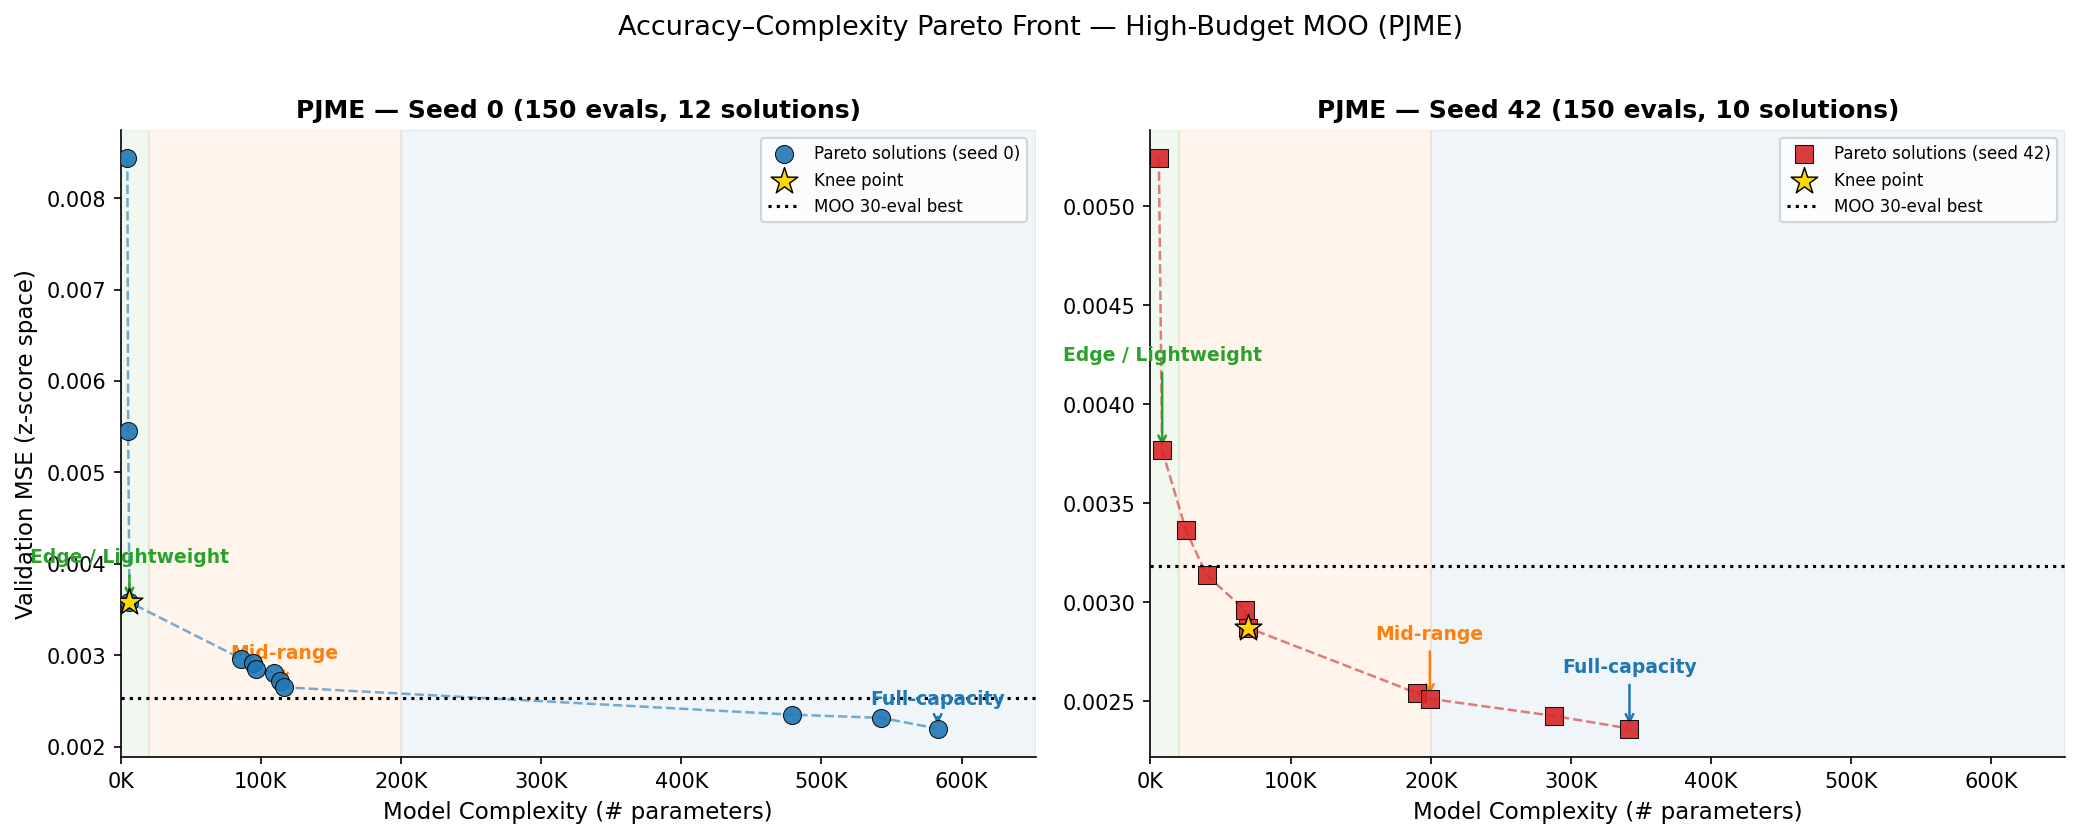

Saved fig4_pareto_front.pdf/.png


In [55]:
# ---------- Figure 4: Pareto Front Plot — unified x-axis ----------
shared_xmax = max(pareto_dfs[s]['complexity'].max() for s in PARETO_SEEDS) * 1.12

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

seed_colors  = {0: '#1f77b4', 42: '#d62728'}
seed_markers = {0: 'o', 42: 's'}

for ax, seed in zip(axes, PARETO_SEEDS):
    pf = pareto_dfs[seed].sort_values('complexity').reset_index(drop=True)

    # Shade deployment tier regions
    for tier_name, (lo, hi) in TIER_BOUNDS.items():
        ax.axvspan(lo, min(hi, shared_xmax),
                   alpha=0.07, color=TIER_COLORS[tier_name])

    # Pareto-front line + scatter
    ax.plot(pf['complexity'], pf['val_mse'],
            color=seed_colors[seed], linestyle='--', linewidth=1.2, alpha=0.6)
    ax.scatter(pf['complexity'], pf['val_mse'],
               color=seed_colors[seed], s=75, zorder=5, alpha=0.9,
               marker=seed_markers[seed], edgecolors='black', linewidths=0.5,
               label=f'Pareto solutions (seed {seed})')

    # Knee point
    ki = find_knee(pf['complexity'].values, pf['val_mse'].values)
    ax.scatter(pf.iloc[ki]['complexity'], pf.iloc[ki]['val_mse'],
               color='gold', s=180, zorder=10, marker='*',
               edgecolors='black', linewidths=0.7, label='Knee point')

    # Tier annotations (>= lo so boundary solutions are not excluded)
    for tier_name, (lo, hi) in TIER_BOUNDS.items():
        sub = pf[(pf['complexity'] >= lo) & (pf['complexity'] <= hi)]
        if len(sub) == 0:
            continue
        best = sub.loc[sub['val_mse'].idxmin()]
        ax.annotate(
            tier_name,
            xy=(best['complexity'], best['val_mse']),
            xytext=(best['complexity'], best['val_mse'] * 1.12),
            fontsize=9, ha='center', color=TIER_COLORS[tier_name], fontweight='bold',
            arrowprops={'arrowstyle': '->', 'color': TIER_COLORS[tier_name], 'lw': 1.2},
        )

    # 30-eval MOO reference line
    moo30 = df[(df['zone'] == 'PJME') & (df['method'] == 'moo') & (df['seed'] == seed)]
    if len(moo30):
        ax.axhline(moo30.iloc[0]['val_mse'], color='black', linestyle=':',
                   linewidth=1.5, label='MOO 30-eval best')

    ax.set_xlabel('Model Complexity (# parameters)')
    ax.set_ylabel('Validation MSE (z-score space)' if seed == PARETO_SEEDS[0] else '')
    ax.set_title(f'PJME — Seed {seed} (150 evals, {pareto_metrics[seed]["n_pareto_solutions"]} solutions)',
                 fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1000:.0f}K'))
    ax.set_xlim(0, shared_xmax)

fig.suptitle('Accuracy–Complexity Pareto Front — High-Budget MOO (PJME)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'fig4_pareto_front.pdf')
plt.savefig(PLOTS_DIR / 'fig4_pareto_front.png')
plt.show()
print('Saved fig4_pareto_front.pdf/.png')


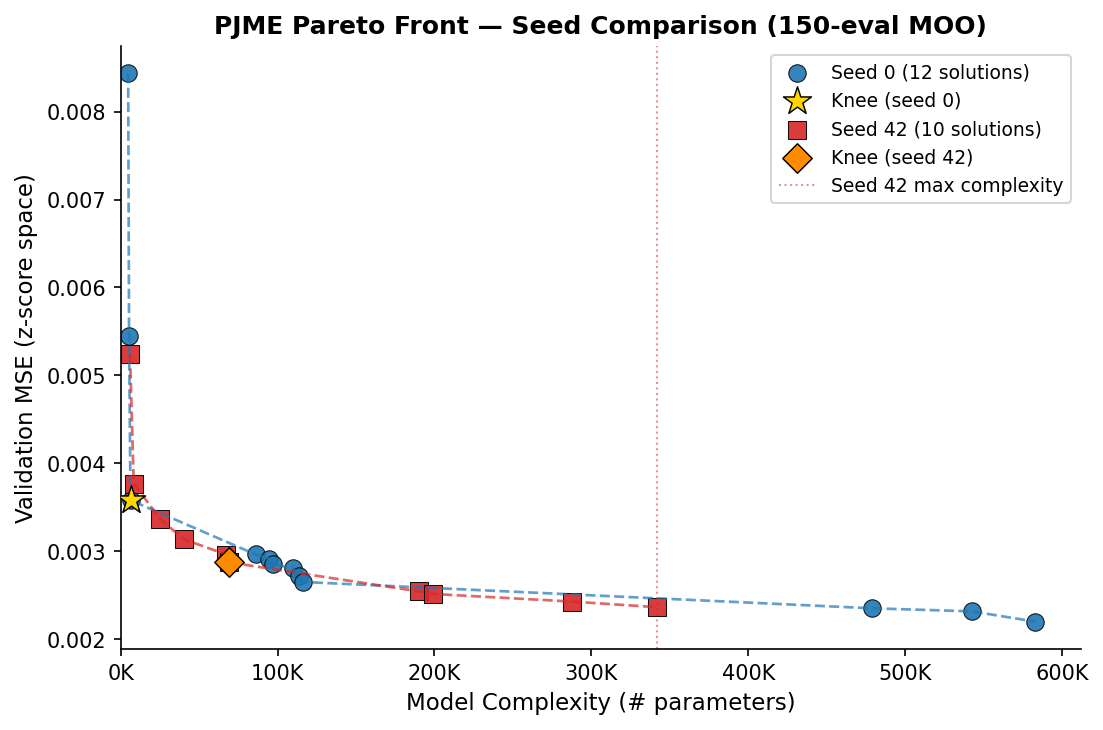

Saved fig5_pareto_overlay.pdf/.png


In [56]:
# ---------- Figure 5: Overlay — distinct knee markers per seed ----------
# Seed 0 knee: gold star; Seed 42 knee: goldenrod diamond (clearly distinguishable)
KNEE_STYLES = {
    0:  {'marker': '*', 'color': 'gold',       's': 200, 'label': 'Knee (seed 0)'},
    42: {'marker': 'D', 'color': 'darkorange',  's': 100, 'label': 'Knee (seed 42)'},
}

fig, ax = plt.subplots(figsize=(7.5, 5))

for seed in PARETO_SEEDS:
    pf = pareto_dfs[seed].sort_values('complexity').reset_index(drop=True)
    ax.plot(pf['complexity'], pf['val_mse'],
            color=seed_colors[seed], linestyle='--', linewidth=1.3, alpha=0.7)
    ax.scatter(pf['complexity'], pf['val_mse'],
               color=seed_colors[seed], s=70, alpha=0.9,
               marker=seed_markers[seed], edgecolors='black', linewidths=0.5,
               label=f'Seed {seed} ({len(pf)} solutions)')

    ki  = find_knee(pf['complexity'].values, pf['val_mse'].values)
    ks  = KNEE_STYLES[seed]
    ax.scatter(pf.iloc[ki]['complexity'], pf.iloc[ki]['val_mse'],
               color=ks['color'], s=ks['s'], zorder=10,
               marker=ks['marker'], edgecolors='black', linewidths=0.7,
               label=ks['label'])

# Mark the extent of seed 42 (shorter front) so reader sees it is not truncated
seed42_max_c = pareto_dfs[42]['complexity'].max()
ax.axvline(seed42_max_c, color='#d62728', linestyle=':', linewidth=1,
           alpha=0.5, label=f'Seed 42 max complexity')

ax.set_xlabel('Model Complexity (# parameters)')
ax.set_ylabel('Validation MSE (z-score space)')
ax.set_title('PJME Pareto Front — Seed Comparison (150-eval MOO)', fontweight='bold')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1000:.0f}K'))
ax.set_xlim(left=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'fig5_pareto_overlay.pdf')
plt.savefig(PLOTS_DIR / 'fig5_pareto_overlay.png')
plt.show()
print('Saved fig5_pareto_overlay.pdf/.png')

---
## Section 8 — Best Configs Table (Table 2)

In [57]:
best_cfg_rows = []
for zone in ZONES:
    for method in METHODS:
        sub  = df[(df['zone'] == zone) & (df['method'] == method)]
        row  = sub.loc[sub['nrmse'].idxmin()]
        best_cfg_rows.append({
            'zone':       zone,
            'method':     METHOD_LABELS[method],
            'best_nrmse': round(row.nrmse, 4),
            'best_seed':  int(row.seed),
            'hidden_dim': int(row.hidden_dim) if row.hidden_dim is not None else None,
            'num_layers': int(row.num_layers) if row.num_layers is not None else None,
            'lr':         round(row.lr, 5)      if row.lr       is not None else None,
            'dropout':    round(row.dropout, 4) if row.dropout  is not None else None,
        })

best_cfg_df = pd.DataFrame(best_cfg_rows)
display(best_cfg_df)
best_cfg_df.to_csv(TABLES_DIR / 'best_configs.csv', index=False)
print('Saved tables/best_configs.csv')

,zone,method,best_nrmse,best_seed,hidden_dim,num_layers,lr,dropout
0,PJME,Baseline,0.0447,24,128,1,0.00400,0.0000
1,PJME,Random Search,0.0394,1981,244,2,0.00483,0.0710
2,PJME,Optuna (TPE),0.0379,247,254,2,0.00469,0.0036
3,PJME,PSO,0.0363,24,236,4,0.00500,0.0000
4,PJME,MOO (NSGA-II),0.0408,0,160,3,0.00316,0.0002
5,AEP,Baseline,0.0601,296,128,1,0.00400,0.0000
6,AEP,Random Search,0.0555,1981,244,2,0.00483,0.0710
7,AEP,Optuna (TPE),0.0537,24,248,3,0.00500,0.0660
8,AEP,PSO,0.0522,247,256,3,0.00500,0.0000
9,AEP,MOO (NSGA-II),0.0535,0,160,3,0.00389,0.0016


Saved tables/best_configs.csv


In [58]:
# ---------- LaTeX: best configs — no Seed column, zone midrules ----------
def make_latex_best_configs(best_cfg_df):
    lines = [
        r'\begin{table}[htbp]',
        r'\centering',
        r'\caption{Best hyperparameter configuration (lowest test NRMSE over 7 seeds)',
        r'         found by each method per zone. $h$ = hidden dim, $L$ = layers,',
        r'         $\eta$ = learning rate.}',
        r'\label{tab:best_configs}',
        r'\begin{tabular}{llccccc}',   # 7 cols: zone, method, nrmse, h, L, lr, dropout
        r'\toprule',
        r'\textbf{Zone} & \textbf{Method} & \textbf{NRMSE} & $h$ & $L$ & $\eta$ & Dropout \\',
        r'\midrule',
    ]
    prev_zone = None
    for _, r in best_cfg_df.iterrows():
        # Midrule between zone blocks (but not before the first zone)
        if prev_zone is not None and r['zone'] != prev_zone:
            lines.append(r'\midrule')
        zlab      = r['zone'] if r['zone'] != prev_zone else ''
        prev_zone = r['zone']
        h   = int(r['hidden_dim']) if r['hidden_dim'] is not None else '---'
        L   = int(r['num_layers']) if r['num_layers'] is not None else '---'
        lr  = f"{r['lr']:.5f}"    if r['lr']       is not None else '---'
        do  = f"{r['dropout']:.4f}" if r['dropout'] is not None else '---'
        lines.append(
            f"{zlab} & {r['method']} & {r['best_nrmse']:.4f}"
            f" & {h} & {L} & {lr} & {do} \\\\"
        )
    lines += [r'\bottomrule', r'\end{tabular}', r'\end{table}']
    return '\n'.join(lines)

latex_bcfg = make_latex_best_configs(best_cfg_df)
(TABLES_DIR / 'best_configs.tex').write_text(latex_bcfg)
print('Saved tables/best_configs.tex\n')
print(latex_bcfg)

Saved tables/best_configs.tex

\begin{table}[htbp]
\centering
\caption{Best hyperparameter configuration (lowest test NRMSE over 7 seeds)
         found by each method per zone. $h$ = hidden dim, $L$ = layers,
         $\eta$ = learning rate.}
\label{tab:best_configs}
\begin{tabular}{llccccc}
\toprule
\textbf{Zone} & \textbf{Method} & \textbf{NRMSE} & $h$ & $L$ & $\eta$ & Dropout \\
\midrule
PJME & Baseline & 0.0447 & 128 & 1 & 0.00400 & 0.0000 \\
 & Random Search & 0.0394 & 244 & 2 & 0.00483 & 0.0710 \\
 & Optuna (TPE) & 0.0379 & 254 & 2 & 0.00469 & 0.0036 \\
 & PSO & 0.0363 & 236 & 4 & 0.00500 & 0.0000 \\
 & MOO (NSGA-II) & 0.0408 & 160 & 3 & 0.00316 & 0.0002 \\
\midrule
AEP & Baseline & 0.0601 & 128 & 1 & 0.00400 & 0.0000 \\
 & Random Search & 0.0555 & 244 & 2 & 0.00483 & 0.0710 \\
 & Optuna (TPE) & 0.0537 & 248 & 3 & 0.00500 & 0.0660 \\
 & PSO & 0.0522 & 256 & 3 & 0.00500 & 0.0000 \\
 & MOO (NSGA-II) & 0.0535 & 160 & 3 & 0.00389 & 0.0016 \\
\midrule
DAYTON & Baseline & 0.0708 & 128

---
## Section 9 — Runtime Table

In [59]:
rt_agg = df.groupby(['zone', 'method']).agg(
    rt_mean_min=('runtime_s', lambda x: x.mean() / 60),
    rt_std_min =('runtime_s', lambda x: x.std()  / 60),
).reset_index()

pivot_rt     = rt_agg.pivot(index='method', columns='zone', values='rt_mean_min').loc[METHODS, ZONES]
pivot_rt_std = rt_agg.pivot(index='method', columns='zone', values='rt_std_min').loc[METHODS, ZONES]

display_rt = pd.DataFrame(index=METHODS, columns=ZONES)
for m in METHODS:
    for z in ZONES:
        mu  = pivot_rt.loc[m, z]
        std = pivot_rt_std.loc[m, z]
        display_rt.loc[m, z] = f'{mu:.1f} ± {std:.1f}'

display_rt.index = [METHOD_LABELS[m] for m in METHODS]
print('Runtime table (minutes, mean ± std over 7 seeds)\n')
display(display_rt)
rt_agg.round(2).to_csv(TABLES_DIR / 'runtimes.csv', index=False)
print('\nSaved tables/runtimes.csv')

Runtime table (minutes, mean ± std over 7 seeds)



,PJME,AEP,DAYTON
Baseline,3.5 ± 0.3,2.7 ± 0.1,2.8 ± 0.2
Random Search,34.4 ± 5.7,36.4 ± 6.1,36.8 ± 5.8
Optuna (TPE),37.1 ± 4.4,36.8 ± 4.5,39.8 ± 6.4
PSO,39.9 ± 5.6,40.5 ± 6.7,41.8 ± 4.7
MOO (NSGA-II),35.7 ± 7.2,33.0 ± 3.2,34.7 ± 3.5



Saved tables/runtimes.csv


In [60]:
# ---------- LaTeX: runtime table ----------
def make_latex_runtimes(pivot_rt, pivot_rt_std, methods, zones):
    col_spec = 'l' + 'c' * len(zones)
    header   = ' & '.join([f'\\textbf{{{z}}}' for z in zones])
    lines = [
        r'\begin{table}[htbp]',
        r'\centering',
        r'\caption{Wall-clock runtime in minutes (mean~$\pm$~std over 7 seeds).',
        r'         Baseline trains one fixed configuration; all others train 30.',
        r'         Experiments run on a single GPU.}',
        r'\label{tab:runtimes}',
        f'\\begin{{tabular}}{{{col_spec}}}',
        r'\toprule',
        f'\\textbf{{Method}} & {header} \\\\',
        r'\midrule',
    ]
    for m in methods:
        parts = [METHOD_LABELS[m]]
        for z in zones:
            mu  = pivot_rt.loc[m, z]
            std = pivot_rt_std.loc[m, z]
            parts.append(f'{mu:.1f}~$\\pm$~{std:.1f}')
        lines.append(' & '.join(parts) + r' \\')
        if m == 'baseline':
            lines.append(r'\midrule')
    lines += [r'\bottomrule', r'\end{tabular}', r'\end{table}']
    return '\n'.join(lines)

latex_rt = make_latex_runtimes(pivot_rt, pivot_rt_std, METHODS, ZONES)
(TABLES_DIR / 'runtimes.tex').write_text(latex_rt)
print('Saved tables/runtimes.tex\n')
print(latex_rt)

Saved tables/runtimes.tex

\begin{table}[htbp]
\centering
\caption{Wall-clock runtime in minutes (mean~$\pm$~std over 7 seeds).
         Baseline trains one fixed configuration; all others train 30.
         Experiments run on a single GPU.}
\label{tab:runtimes}
\begin{tabular}{lccc}
\toprule
\textbf{Method} & \textbf{PJME} & \textbf{AEP} & \textbf{DAYTON} \\
\midrule
Baseline & 3.5~$\pm$~0.3 & 2.7~$\pm$~0.1 & 2.8~$\pm$~0.2 \\
\midrule
Random Search & 34.4~$\pm$~5.7 & 36.4~$\pm$~6.1 & 36.8~$\pm$~5.8 \\
Optuna (TPE) & 37.1~$\pm$~4.4 & 36.8~$\pm$~4.5 & 39.8~$\pm$~6.4 \\
PSO & 39.9~$\pm$~5.6 & 40.5~$\pm$~6.7 & 41.8~$\pm$~4.7 \\
MOO (NSGA-II) & 35.7~$\pm$~7.2 & 33.0~$\pm$~3.2 & 34.7~$\pm$~3.5 \\
\bottomrule
\end{tabular}
\end{table}


---
## Section 10 — Key Findings Summary

In [61]:
print('=' * 70)
print('KEY QUANTITATIVE FINDINGS')
print('=' * 70)

# --- Equal-budget comparison ---
print('\n--- Equal-budget comparison (30 evals) ---')
for zone in ZONES:
    bl_mean = agg[(agg['zone'] == zone) & (agg['method'] == 'baseline')]['nrmse_mean'].values[0]
    print(f'\n  Zone: {zone}  (Baseline NRMSE = {bl_mean:.4f})')
    for m in ['random_search', 'optuna', 'pso', 'moo']:
        r   = agg[(agg['zone'] == zone) & (agg['method'] == m)].iloc[0]
        imp = r['nrmse_improv_pct']
        print(f'    {METHOD_LABELS[m]:<20}: {r.nrmse_mean:.4f} ± {r.nrmse_std:.4f}  '
              f'({imp:+.1f}% vs baseline)')

# --- Overall ranking ---
print('\n--- Overall ranking (mean NRMSE averaged across 3 zones) ---')
overall = agg.groupby('method')['nrmse_mean'].mean().sort_values()
for m, v in overall.items():
    print(f'    {METHOD_LABELS[m]:<20}: {v:.4f}')

# --- Pareto vs 30-eval Optuna/PSO ---
print('\n--- High-budget Pareto (150 evals) vs best 30-eval single-objective (PJME) ---')
opt30 = agg[(agg['zone'] == 'PJME') & (agg['method'] == 'optuna')]['nrmse_mean'].values[0]
pso30 = agg[(agg['zone'] == 'PJME') & (agg['method'] == 'pso')]  ['nrmse_mean'].values[0]
for seed in PARETO_SEEDS:
    nrmse = pareto_metrics[seed]['best_test_nrmse']
    print(f'    Pareto seed {seed}: NRMSE = {nrmse:.4f}  '
          f'(Optuna 30-eval mean: {opt30:.4f}, PSO 30-eval mean: {pso30:.4f})')

# --- MOO instability ---
print('\n--- MOO vs Optuna NRMSE std (instability comparison) ---')
for z in ZONES:
    ms = agg[(agg['zone'] == z) & (agg['method'] == 'moo')]   ['nrmse_std'].values[0]
    os = agg[(agg['zone'] == z) & (agg['method'] == 'optuna')]['nrmse_std'].values[0]
    print(f'    {z}: MOO std = {ms:.4f}, Optuna std = {os:.4f}  (ratio {ms/os:.1f}x)')

# --- Pareto front span ---
print('\n--- Pareto front accuracy-complexity span (PJME) ---')
for seed in PARETO_SEEDS:
    pf = pareto_dfs[seed].sort_values('complexity')
    lightest = pf.iloc[0]
    heaviest = pf.iloc[-1]
    ratio    = lightest.val_mse / heaviest.val_mse
    print(f'    Seed {seed}:')
    print(f'      Lightest: {int(lightest.complexity):>8,} params — val_mse = {lightest.val_mse:.5f}')
    print(f'      Heaviest: {int(heaviest.complexity):>8,} params — val_mse = {heaviest.val_mse:.5f}')
    print(f'      Val MSE ratio (lightest / heaviest): {ratio:.2f}x')

# --- Wilcoxon key call-outs (data-driven — no hardcoded claims) ---
print('\n--- Wilcoxon key findings (vs Baseline) ---')
vs_bl = wil_df[wil_df['method_b'] == 'Baseline'].sort_values(['zone', 'method_a'])
for _, r in vs_bl.iterrows():
    if r['a_worse']:
        note = f'p={r["p_value"]:.3f}  [n.s. or sig. WORSE — method_a has higher mean NRMSE]'
    elif r['sig_5pct']:
        note = f'p={r["p_value"]:.3f}  [*sig. improvement*]'
    else:
        note = f'p={r["p_value"]:.3f}  [n.s.]'
    direction = '▲ worse' if r['mean_a'] > r['mean_b'] else '▼ better'
    print(f'    {r["zone"]}: {r["method_a"]:<20} vs Baseline — {direction} — {note}')

print('\n--- Wilcoxon pairwise (non-baseline) ---')
pairwise = wil_df[wil_df['method_b'] != 'Baseline'].sort_values(['zone', 'p_value'])
sig_pairs = pairwise[pairwise['sig_5pct']]
if len(sig_pairs):
    print('  Significant pairwise tests (p < 0.05):')
    for _, r in sig_pairs.iterrows():
        print(f'    {r["zone"]}: {r["method_a"]} vs {r["method_b"]}, p={r["p_value"]:.3f}')
else:
    print('  No pairwise optimiser-vs-optimiser test is significant.')


KEY QUANTITATIVE FINDINGS

--- Equal-budget comparison (30 evals) ---

  Zone: PJME  (Baseline NRMSE = 0.0454)
    Random Search       : 0.0427 ± 0.0020  (+5.9% vs baseline)
    Optuna (TPE)        : 0.0407 ± 0.0024  (+10.3% vs baseline)
    PSO                 : 0.0416 ± 0.0038  (+8.4% vs baseline)
    MOO (NSGA-II)       : 0.0458 ± 0.0047  (-0.8% vs baseline)

  Zone: AEP  (Baseline NRMSE = 0.0606)
    Random Search       : 0.0586 ± 0.0022  (+3.3% vs baseline)
    Optuna (TPE)        : 0.0576 ± 0.0028  (+5.0% vs baseline)
    PSO                 : 0.0549 ± 0.0032  (+9.4% vs baseline)
    MOO (NSGA-II)       : 0.0621 ± 0.0056  (-2.3% vs baseline)

  Zone: DAYTON  (Baseline NRMSE = 0.0713)
    Random Search       : 0.0689 ± 0.0018  (+3.5% vs baseline)
    Optuna (TPE)        : 0.0669 ± 0.0024  (+6.2% vs baseline)
    PSO                 : 0.0680 ± 0.0023  (+4.7% vs baseline)
    MOO (NSGA-II)       : 0.0729 ± 0.0038  (-2.2% vs baseline)

--- Overall ranking (mean NRMSE averaged across 